In [40]:
import matplotlib.pyplot as plt

from network import Network
from fc_layer import FCLayer
from activation_layer import ActivationLayer
from activations import tanh, tanh_prime
from losses import mse, mse_prime

from keras import datasets
from keras import utils

In [41]:
sample = 86

In [42]:
# Load mnist data from server
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

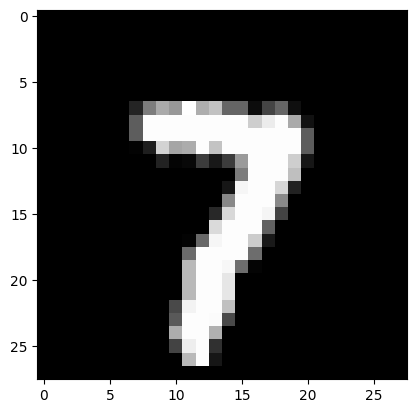

In [43]:
img = x_test[sample]
fig = plt.figure
plt.imshow(img, cmap='gray')
plt.show()

In [44]:
# Training data: 60000 samples
# Reshape and normalize input data
x_train = x_train.reshape(x_train.shape[0], 1, 28*28)
x_train = x_train.astype('float32')
x_train /= 255

# Encode output which is a number in range [0, 9] into a vector of size 10
# e.g. number 3 will become [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# OneHotEncode basically
y_train = utils.to_categorical(y_train, 10)

# Same for test data : 10000 samples
x_test = x_test.reshape(x_test.shape[0], 1, 28*28)
x_test = x_test.astype('float32')
x_test /= 255
y_test = utils.to_categorical(y_test, 10)

In [45]:
# Network
net = Network()
net.add(FCLayer(28*28, 100))
net.add(ActivationLayer(tanh, tanh_prime))
net.add(FCLayer(100, 50))
net.add(ActivationLayer(tanh, tanh_prime))
net.add(FCLayer(50, 10))
net.add(ActivationLayer(tanh, tanh_prime))

In [46]:
# Train on 1000 samples
# as we didn't implement mini-batch GD, training will be pretty slow if we update at each iteration on 60000 samples....
net.use(mse, mse_prime)
net.fit(x_train[0:1000], y_train[0:1000], epochs=35, learning_rate=0.1)

epoch 1/35 error=0.897229
epoch 2/35 error=0.840112
epoch 3/35 error=0.800120
epoch 4/35 error=0.744036
epoch 5/35 error=0.604276
epoch 6/35 error=0.263237
epoch 7/35 error=0.201307
epoch 8/35 error=0.186008
epoch 9/35 error=0.182879
epoch 10/35 error=0.178882
epoch 11/35 error=0.177555
epoch 12/35 error=0.176233
epoch 13/35 error=0.177067
epoch 14/35 error=0.175862
epoch 15/35 error=0.174851
epoch 16/35 error=0.173983
epoch 17/35 error=0.174249
epoch 18/35 error=0.173613
epoch 19/35 error=0.173003
epoch 20/35 error=0.171680
epoch 21/35 error=0.169898
epoch 22/35 error=0.168177
epoch 23/35 error=0.167122
epoch 24/35 error=0.166210
epoch 25/35 error=0.165358
epoch 26/35 error=0.164647
epoch 27/35 error=0.163504
epoch 28/35 error=0.163235
epoch 29/35 error=0.162427
epoch 30/35 error=0.162515
epoch 31/35 error=0.162122
epoch 32/35 error=0.161768
epoch 33/35 error=0.161658
epoch 34/35 error=0.161241
epoch 35/35 error=0.161148


In [47]:
out = net.predict(x_test[sample])
print("\n")
print(out)



[array([[ 0.18477889, -0.07266926, -0.09038597,  0.50518691, -0.15121403,
        -0.19799937,  0.60277007,  0.94606158, -0.12617293, -0.15814464]])]


In [48]:
max_num, max_num2 = -1, -1
for i, num in enumerate(zip(out[0][0], y_test[sample])):
  if num[0] > max_num:
    max_num = num[0]
    pred_ans = i
  if num[1] > max_num2:
    max_num2 = num[1]
    true_ans = i
print(f"Predicted : {pred_ans}, Actual : {true_ans}")

Predicted : 7, Actual : 7
